# Locating an earthquake with matched-field processing

Matched-field processing (MFP) extends plane-wave beamforming to three
dimensions by replacing the plane-wave steering vector with a
*replica* — a predicted wavefield for a point source at each candidate
grid location. This allows simultaneous estimation of back-azimuth,
horizontal range, and **depth**.

This example locates the Mb 4.4 earthquake that occurred in the Aegean Sea
on 5 October 2020 (39.88°N, 23.35°E, 10 km depth), using the same regional
network as the back-projection example. We demonstrate:

1. Building a constant-velocity model over the network area,
2. Computing per-station travel-time grids with
   `covseisnet.travel_times.TravelTimes`,
3. Validating the Bartlett and MVDR processors on a synthetic covariance
   injected at the known epicentre,
4. Applying the processors to the real earthquake covariance and comparing
   the recovered location with the catalogue position.


In [1]:
from cartopy.crs import PlateCarree
import numpy as np
import matplotlib.pyplot as plt

import covseisnet as csn
from covseisnet.matchedfield import MatchedFieldProcessing
import covseisnet.synthetic as syn

## Load seismograms and station coordinates

We load the Aegean Sea example data, download the station inventory from the
National Observatory of Athens (NOA), and pre-process the waveforms exactly
as in the back-projection example: merge, detrend, high-pass filter, and
synchronise. We also plot the station map with the known catalogue epicentre,
and capture the map extent for use in the velocity model grid.


Array: 9 stations


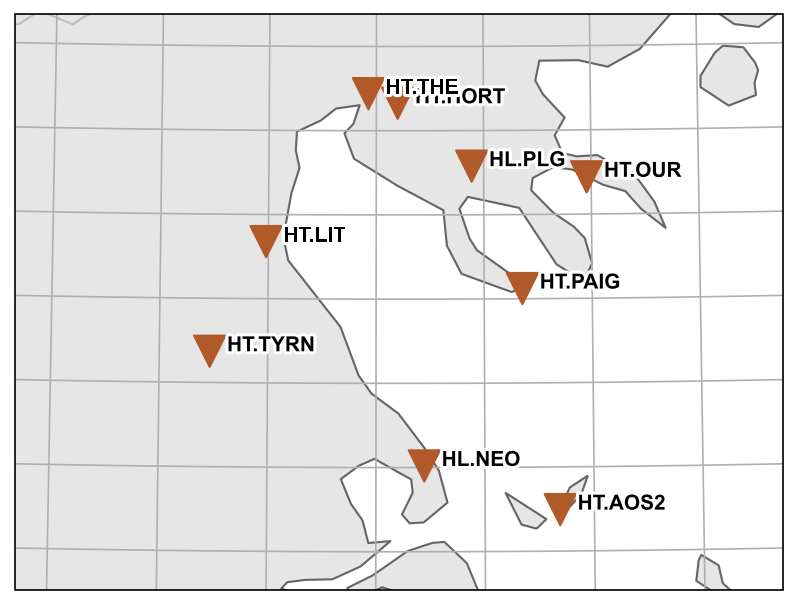

In [2]:
# Load seismograms
stream = csn.NetworkStream.read("../data/aegean_sea_example.mseed")

# Pre-process
stream.merge(1, fill_value=0)
stream.detrend("linear")
stream.filter("highpass", freq=0.01)
stream.synchronize()

# Download inventory and attach coordinates
inventory = stream.download_inventory(datacenter="NOA")
stream.assign_coordinates(inventory)

stats = [tr.stats for tr in stream]
n_stations = len(stats)
lons = np.array([s.coordinates["longitude"] for s in stats])
lats = np.array([s.coordinates["latitude"] for s in stats])
print(f"Array: {n_stations} stations")

# Known catalogue location (lon, lat, depth_km)
source_location = (23.3465, 39.8812, 10.0)

# Station map with catalogue epicentre
fig = inventory.plot(projection="local", resolution="h")
fig.axes[0].plot(
    *source_location[:2],
    "k*",
    markersize=20,
    transform=PlateCarree(),
    label="Catalogue",
)

# Natural extent of the map (reused for the velocity-model grid)
extent = fig.axes[0].get_extent(crs=PlateCarree())

## Velocity model and travel times

We build a constant-velocity model at 3.5 km/s (S-wave dominated) over the
geographic extent returned by the station map, extended from −3 to 20 km
depth to encompass both shallow and crustal sources. For each station we
compute the travel time from every grid point to that receiver.


In [11]:
# Append depth range to the horizontal extent from the map
extent_with_depth = extent + (-3, 20)

velocity_model = csn.velocity.VelocityModel(
    extent=extent_with_depth, shape=(60, 60, 40), velocity=3.5
)

# Per-station travel-time grids
travel_times = {
    tr.stats.station: csn.calculate_travel_times(
        velocity_model, stats=tr.stats
    )
    for tr in stream
}
print(f"TravelTimes grid shape: {next(iter(travel_times.values())).shape}")

# Station coordinates for plotting
receiver_coords = None

TravelTimes grid shape: (60, 60, 40)


(<Figure size 750x750 with 4 Axes>,
 {'xy': <Axes: label='xy', ylabel='Latitude (º)'>,
  'zy': <Axes: label='zy', xlabel='Depth (km)'>,
  'xz': <Axes: label='xz', xlabel='Longitude (º)', ylabel='Depth (km)'>,
  'cb': <Axes: label='cb'>})

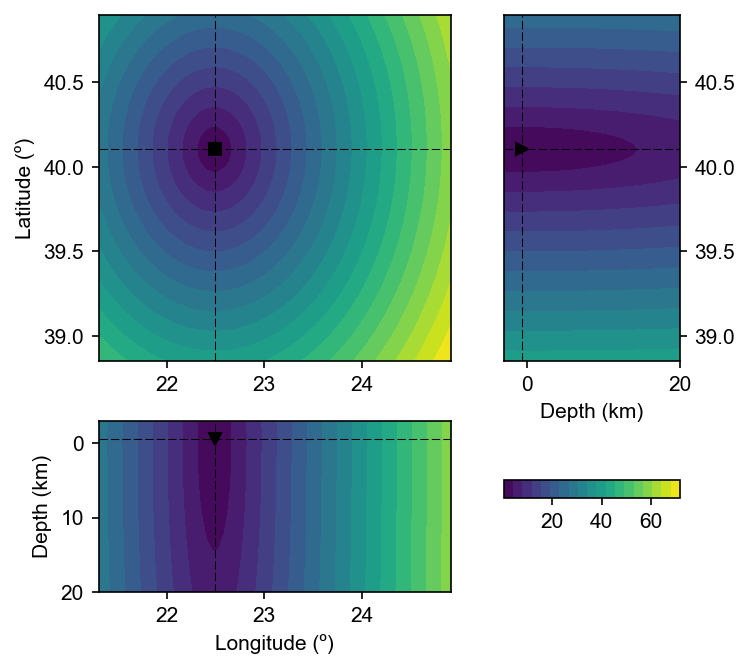

In [12]:
csn.plot.grid3d(
    travel_times["LIT"],
    # receiver_coords=receiver_coords,
    # source_location=source_location,
)

In [13]:
(travel_times["LIT"].lon[1] - travel_times["LIT"].lon[0]) * 111

np.float64(6.782131466347639)

## Validation on a synthetic spherical wave

Before applying MFP to the real earthquake we verify the implementation by
injecting a synthetic rank-1 covariance at the catalogue epicentre (23.35°E,
39.88°N, 10 km depth) and checking that the Bartlett processor recovers that
location.


In [14]:
source = source_location
frequency = 0.1  # Hz — wavelength ~70 km, well above grid spacing (~12 km)
slowness = 1 / 3.5  # s/km — matching the velocity model

cov_synth = syn.spherical_wave_covariance(stats, frequency, slowness, source)
cov_synth /= np.abs(cov_synth)

mfp = MatchedFieldProcessing(travel_times)
mfp.compute_bartlett(cov_synth, frequency)

lon_det, lat_det, dep_det = mfp.maximum_coordinates()
print(
    f"True source  : lon={source[0]:.3f}° lat={source[1]:.3f}° depth={source[2]:.1f} km"
)
print(
    f"MFP estimate : lon={lon_det:.3f}° lat={lat_det:.3f}° depth={dep_det:.1f} km"
)

True source  : lon=23.346° lat=39.881° depth=10.0 km
MFP estimate : lon=23.320° lat=39.894° depth=0.5 km


Text(0.5, 1.0, 'Synthetic — Bartlett MFP')

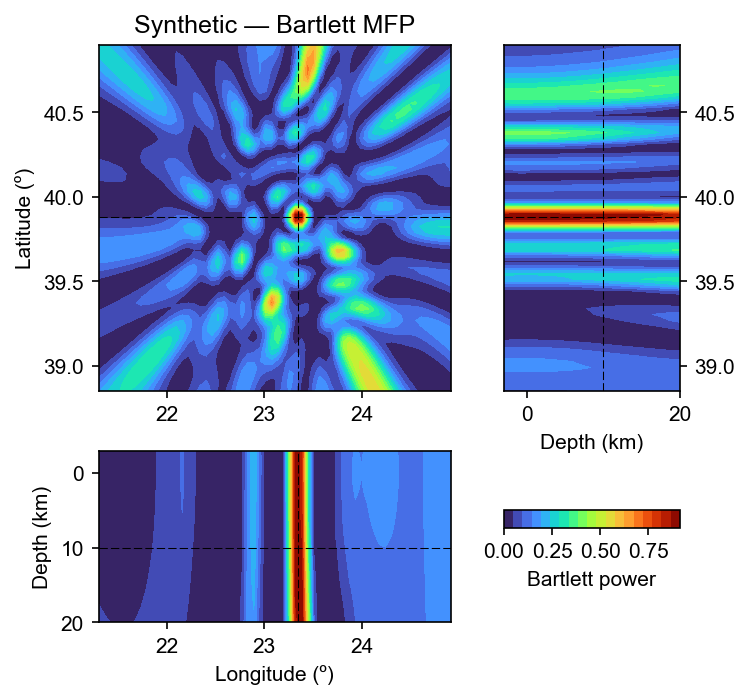

In [15]:
fig, ax = csn.plot.grid3d(
    mfp,
    profile_coordinates=source,
    cmap="turbo",
    label="Bartlett power",
)
ax["xy"].set_title("Synthetic — Bartlett MFP")

## MVDR matched-field processor

The MVDR (minimum-variance distortionless-response) processor typically
achieves higher spatial resolution than Bartlett by suppressing the
sidelobe structure at the cost of a matrix inversion.  We apply it to
the same synthetic covariance and compare the horizontal slice with the
Bartlett result.

MVDR estimate: lon=23.320° lat=39.894° depth=0.5 km


Text(0.5, 1.0, 'Synthetic — MVDR MFP')

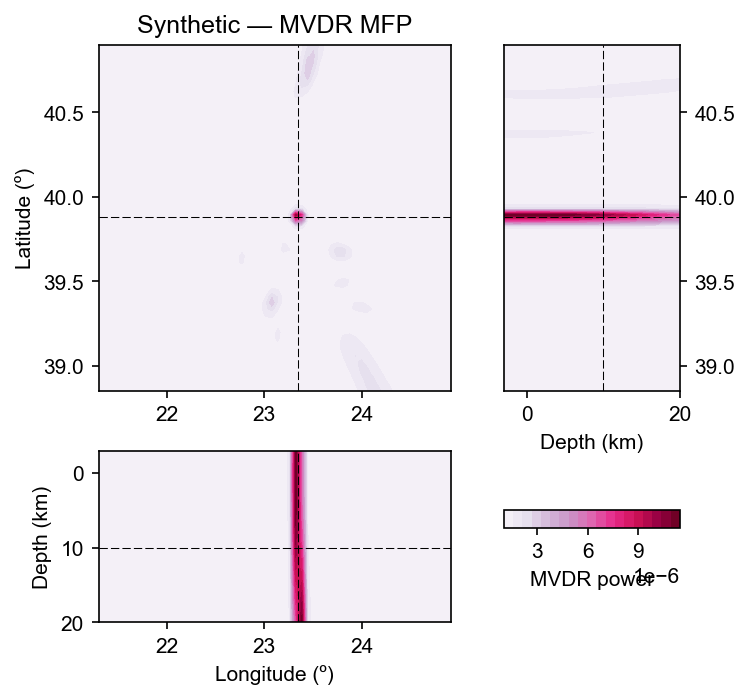

In [16]:
mfp_mvdr = MatchedFieldProcessing(travel_times)
mfp_mvdr.compute_mvdr(cov_synth, frequency)

lon_mv, lat_mv, dep_mv = mfp_mvdr.maximum_coordinates()
print(
    f"MVDR estimate: lon={lon_mv:.3f}° lat={lat_mv:.3f}° depth={dep_mv:.1f} km"
)

fig, ax = csn.plot.grid3d(
    mfp_mvdr,
    profile_coordinates=source,
    cmap="PuRd",
    label="MVDR power",
)
ax["xy"].set_title("Synthetic — MVDR MFP")

## Application to the real earthquake recording

Two constraints set the usable frequency band:

1. **Spatial sampling**: the Bartlett steering vector $e^{-2\pi i f \tau}$
   oscillates at wavelength $\lambda = v/f$. Correct resolution requires at
   least two grid points per wavelength. With a horizontal grid spacing of
   ~15–20 km, frequencies above ~0.1 Hz are aliased and the power maximum
   lands at an arbitrary grid point.

2. **Incoherent stacking**: at a single frequency the Bartlett map contains
   grating lobes. Averaging the power incoherently over a frequency band
   suppresses them because the lobes shift with frequency while the true
   source maximum stays fixed.

We therefore filter the data to 0.02–0.1 Hz (surface-wave dominated), use a
300 s window to capture all regional arrivals, and stack the Bartlett power
over the band.


In [ ]:
# Work on a copy so accumulated filters don't contaminate the stream
stream_lf = stream.copy()
stream_lf.filter("bandpass", freqmin=0.02, freqmax=0.1)

# 300 s window captures all regional surface-wave arrivals
times, frequencies, covariances = csn.calculate_covariance_matrix(
    stream_lf, window_duration=300, average=1, whiten="none"
)

# Frequency band for incoherent stacking
fmin, fmax = 0.02, 0.1
freq_mask = (frequencies >= fmin) & (frequencies <= fmax)
print(f"Stacking {freq_mask.sum()} frequency bins ({fmin}–{fmax} Hz)")

Using frequency 0.100 Hz


MFP estimate : lon=23.337° lat=39.324° depth=20.0 km
Catalogue    : lon=23.346° lat=39.881° depth=10.0 km


Text(0.5, 1.0, 'Real data — Bartlett MFP at 0.10 Hz')

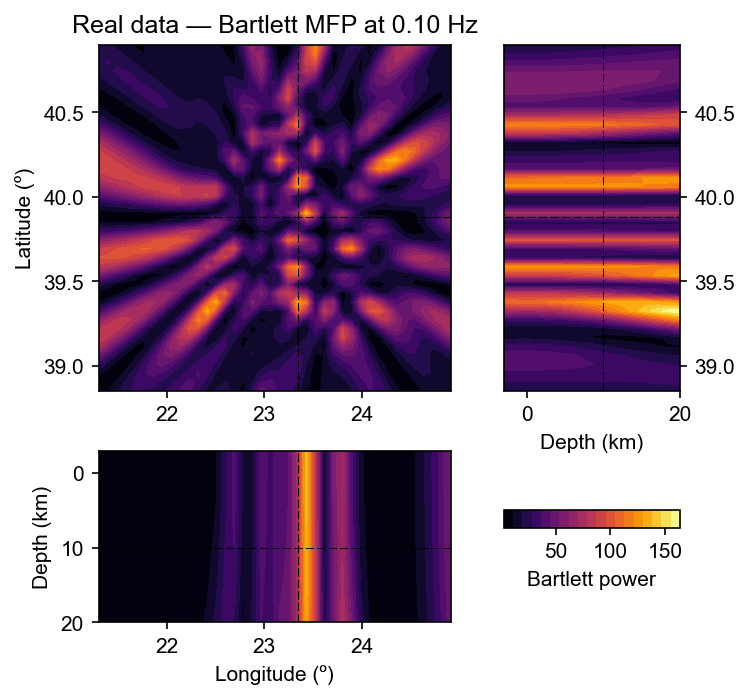

In [ ]:
# Incoherent frequency stacking over the 0.02–0.1 Hz band
power_stack = np.zeros(next(iter(travel_times.values())).shape)
for f, cov_f in zip(frequencies[freq_mask], covariances[0, freq_mask]):
    mfp_f = MatchedFieldProcessing(travel_times)
    mfp_f.compute_bartlett(cov_f, f)
    power_stack += np.nan_to_num(mfp_f)
power_stack /= freq_mask.sum()

# Store in a MatchedFieldProcessing object so grid3d can plot it
mfp_real = MatchedFieldProcessing(travel_times)
mfp_real[...] = power_stack

lon_r, lat_r, dep_r = mfp_real.maximum_coordinates()
print(f"MFP estimate : lon={lon_r:.3f}° lat={lat_r:.3f}° depth={dep_r:.1f} km")
print(
    f"Catalogue    : lon={source[0]:.3f}° lat={source[1]:.3f}° depth={source[2]:.1f} km"
)

fig, ax = csn.plot.grid3d(
    mfp_real,
    profile_coordinates=source_location,
    cmap="inferno",
    label="Bartlett power (0.02–0.1 Hz stack)",
)
ax["xy"].set_title(f"Real data — Bartlett MFP ({fmin}–{fmax} Hz)")